# Ноутбук 1: Аудит данных.

## 1. ВВЕДЕНИЕ

**Цель этого этапа** — провести аудит данных, полученных от клиента
(выгрузки из CRM, складской системы, личного кабинета маркетплейса),
оценить их качество и подготовить к дальнейшему анализу.

Шесть таблиц, которые я проверяю:
 - `products.csv`    — справочник товаров
 - `customers.csv`   — база клиентов
 - `sales.csv`       — журнал продаж (заказы)
 - `purchases.csv`   — журнал закупок у поставщиков
 - `returns.csv`     — журнал возвратов
 - `logistics_costs.csv` — логистические затраты

**Критерии качества:**
 - **Полнота**: нет ли критичных пропусков?
 - **Целостность**: связаны ли таблицы корректно?
 - **Непротиворечивость**: даты, суммы, остатки
 - **Отсутствие дубликатов**: клиенты, заказы, товары

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from datetime import datetime
from collections import defaultdict
from difflib import SequenceMatcher

warnings.filterwarnings('ignore')

In [2]:
# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Цвета для визуализаций
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'warning': '#C73E1D',
    'success': '#3B1F2B',
    'categories': ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#6A994E']
}

## 2. ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ ОСМОТР

In [3]:
# Загрузка всех таблиц
DATA_PATH = "data/"

files = {
    "products": "products.csv",
    "customers": "customers.csv",
    "sales": "sales.csv",
    "purchases": "purchases.csv",
    "returns": "returns.csv",
    "logistics_costs": "logistics_costs.csv",
}

datasets = {}
for name, filename in files.items():
    filepath = os.path.join(DATA_PATH, filename)
    if os.path.exists(filepath):
        datasets[name] = pd.read_csv(filepath)
        print(f"✓ {filename}: загружено {len(datasets[name]):,} строк")
    else:
        print(f"✗ {filename}: файл не найден!")

✓ products.csv: загружено 3,000 строк
✓ customers.csv: загружено 5,000 строк
✓ sales.csv: загружено 58,664 строк
✓ purchases.csv: загружено 3,717 строк
✓ returns.csv: загружено 3,519 строк
✓ logistics_costs.csv: загружено 115,880 строк


In [4]:
# Приведение дат к datetime
date_columns = {
    "customers": ["registration_date"],
    "sales": ["order_date", "delivery_date"],
    "purchases": ["purchase_date", "delivery_date"],
    "returns": ["return_date", "return_to_stock_date"],
    "logistics_costs": ["cost_date"],
}

for name, cols in date_columns.items():
    if name in datasets:
        for col in cols:
            if col in datasets[name].columns:
                datasets[name][col] = pd.to_datetime(datasets[name][col], errors='coerce')

In [5]:
# Формирую сводную таблицу
summary_rows = []
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    missing_pct = (total_missing / (len(df) * len(df.columns))) * 100
    
    # Диапазон дат
    date_cols_in_df = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    date_range = ""
    if date_cols_in_df:
        min_dates = []
        max_dates = []
        for dc in date_cols_in_df:
            if df[dc].notna().any():
                min_dates.append(df[dc].min())
                max_dates.append(df[dc].max())
        if min_dates:
            date_range = f"{min(min_dates).strftime('%Y-%m-%d')} — {max(max_dates).strftime('%Y-%m-%d')}"
    
    summary_rows.append({
        "Таблица": name,
        "Строк": f"{len(df):,}",
        "Столбцов": len(df.columns),
        "Пропусков": f"{total_missing} ({missing_pct:.1f}%)",
        "Диапазон дат": date_range if date_range else "Н/Д",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

        Таблица   Строк  Столбцов    Пропусков            Диапазон дат
       products   3,000        12     0 (0.0%)                     Н/Д
      customers   5,000         9     0 (0.0%) 2023-01-03 — 2025-12-19
          sales  58,664         9     0 (0.0%) 2024-01-01 — 2026-01-10
      purchases   3,717         9     0 (0.0%) 2023-12-22 — 2026-01-03
        returns   3,519        10  1042 (3.0%) 2024-01-08 — 2026-01-23
logistics_costs 115,880         8 53697 (5.8%) 2024-01-01 — 2026-01-21


In [6]:
# Вывожу первые 3 строки каждой таблицы
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    print(f"Колонки: {', '.join(df.columns.tolist())}")
    display(df.head(3))
    print(f"... всего {len(df):,} строк")


--- PRODUCTS ---
Колонки: product_id, product_name, category, subcategory, base_cost, base_price, weight_kg, volume_l, supplier, abc_class, warehouse_type, is_active


,product_id,product_name,category,subcategory,base_cost,base_price,weight_kg,volume_l,supplier,abc_class,warehouse_type,is_active
0,1,Пемолюкс гель для стирки 3л,Бытовая химия,Стиральные порошки,138.56,210.78,0.859,4.550,ХимТорг,C,FBS,True
1,2,ЧистоМир гель для стирки 1.9л,Бытовая химия,Стиральные порошки,271.76,400.35,1.121,2.167,БытПром,B,FBO,True
2,3,Пемолюкс гель для стирки 1.4л,Бытовая химия,Стиральные порошки,154.03,231.88,2.185,1.333,БытПром,C,FBO,True


... всего 3,000 строк

--- CUSTOMERS ---
Колонки: customer_id, full_name, email, phone, city, region, registration_date, client_type, total_orders


,customer_id,full_name,email,phone,city,region,registration_date,client_type,total_orders
0,1,Павлов Евгений Кириллович,evgeniy.pavlov1680@mail.ru,79755321413,Москва,Москва,2024-06-03,B2C,5
1,2,"ИП ""ГарантСтрой""",garantstroy.ip70@yandex.ru,79285598545,Тюмень,Тюменская область,2025-07-30,B2B,2
2,3,Семёнов Егор Юрьевич,egor.semyonov1520@inbox.ru,79124675487,Московская область,Московская область,2025-01-06,B2C,4


... всего 5,000 строк

--- SALES ---
Колонки: order_id, product_id, customer_id, order_date, delivery_date, quantity, unit_price, discount_pct, warehouse_type


...

... всего 3,717 строк

--- RETURNS ---
Колонки: return_id, order_id, product_id, customer_id, return_date, return_reason, return_status, refund_amount, return_logistics_cost, return_to_stock_date


,return_id,order_id,product_id,customer_id,return_date,return_reason,return_status,refund_amount,return_logistics_cost,return_to_stock_date
0,1,15184,136,3438,2025-06-20,Ошибка в заказе (не тот товар),Возвращён в оборот,400.52,103,2025-06-23
1,2,2657,1111,1555,2024-04-18,Не соответствует описанию / ожиданиям,Возвращён в оборот,702.83,132,2024-04-20
2,3,599,909,5,2024-02-05,Повреждение при доставке,Возвращён в оборот,434.73,142,2024-02-08


... всего 3,519 строк

--- LOGISTICS_COSTS ---
Колонки: cost_id, order_id, product_id, cost_date, cost_type, cost_amount, warehouse_type, details


,cost_id,order_id,product_id,cost_date,cost_type,cost_amount,warehouse_type,details
0,1,1.0,646.0,2024-01-01,delivery_to_pvz,64.80,FBS,"Вес: 0.16кг, коэф: 1.2"
1,2,1.0,1906.0,2024-01-01,delivery_to_pvz,49.52,FBO,"Вес: 0.751кг, коэф: 1.2"
2,3,1.0,106.0,2024-01-01,delivery_to_pvz,95.55,FBS,"Вес: 1.185кг, коэф: 1.2"


... всего 115,880 строк


In [7]:
# Вывожу данные info по всем таблицам:
for name, df in datasets.items():
    print(f"\n--- {name}.info() ---")
    df.info()


--- products.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      3000 non-null   int64  
 1   product_name    3000 non-null   object 
 2   category        3000 non-null   object 
 3   subcategory     3000 non-null   object 
 4   base_cost       3000 non-null   float64
 5   base_price      3000 non-null   float64
 6   weight_kg       3000 non-null   float64
 7   volume_l        3000 non-null   float64
 8   supplier        3000 non-null   object 
 9   abc_class       3000 non-null   object 
 10  warehouse_type  3000 non-null   object 
 11  is_active       3000 non-null   bool   
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 260.9+ KB

--- customers.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column             Non-Null 

### Качество данных: типы
- **Проблема:** `customers.phone` загрузился как `int64`, а не как строка. Это означает, что при экспорте/импорте могли потеряться лидирующие "+7" или дефисы. Нужно привести к строковому типу и восстановить формат.
- `logistics_costs.order_id` и `product_id` имеют тип `float64` (а не `int64`) из-за наличия NaN — для аналитики это допустимо.

In [8]:
# phone в customers — из int64 в строку, восстановление формата
# Проблема: телефон загрузился как число, потерян префикс +
datasets["customers"]["phone"] = "+" + datasets["customers"]["phone"].astype(str)

print("✓ customers.phone приведён к строковому типу, формат +7XXXXXXXXXX")

# id-поля в logistics_costs с float64 на Int64 (pandas nullable integer)
# Проблема: из-за NaN эти колонки стали float64, что нелогично для ID
datasets["logistics_costs"]["order_id"] = datasets["logistics_costs"]["order_id"].astype("Int64")
datasets["logistics_costs"]["product_id"] = datasets["logistics_costs"]["product_id"].astype("Int64")
print("✓ logistics_costs.order_id и product_id приведены к Int64 (nullable)")

# Категориальные поля — оптимизация памяти
# Перевожу в category только те object-колонки, где количество уникальных значений
# существенно меньше количества строк (иначе category даст обратный эффект)
categorical_cols = {
    "products": ["category", "subcategory", "abc_class", "warehouse_type", "supplier"],
    "customers": ["city", "region", "client_type"],
    "sales": ["warehouse_type"],
    "purchases": ["warehouse_type", "supplier"],
    "returns": ["return_reason", "return_status"],
    "logistics_costs": ["cost_type", "warehouse_type"],  # details НЕ включаю — там уникальные строки
}

for name, cols in categorical_cols.items():
    for col in cols:
        if col in datasets[name].columns:
            n_unique = datasets[name][col].nunique()
            n_rows = len(datasets[name])
            # Перевожу в category, только если уникальных значений < 50% от строк
            if n_unique < n_rows * 0.5:
                datasets[name][col] = datasets[name][col].astype("category")
                print(f"  ✓ {name}.{col} → category ({n_unique} уникальных, {n_rows} строк)")
            else:
                print(f"  → {name}.{col} оставлен как object ({n_unique} уникальных — слишком много для category)")

# Проверяю память после оптимизации
print("\nИспользование памяти после оптимизации:")
for name, df in datasets.items():
    mem_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"  {name}: {mem_mb:.1f} MB")

✓ customers.phone приведён к строковому типу, формат +7XXXXXXXXXX
✓ logistics_costs.order_id и product_id приведены к Int64 (nullable)
  ✓ products.category → category (6 уникальных, 3000 строк)
  ✓ products.subcategory → category (19 уникальных, 3000 строк)
  ✓ products.abc_class → category (3 уникальных, 3000 строк)
  ✓ products.warehouse_type → category (2 уникальных, 3000 строк)
  ✓ products.supplier → category (18 уникальных, 3000 строк)
  ✓ customers.city → category (30 уникальных, 5000 строк)
  ✓ customers.region → category (30 уникальных, 5000 строк)
  ✓ customers.client_type → category (2 уникальных, 5000 строк)
  ✓ sales.warehouse_type → category (2 уникальных, 58664 строк)
  ✓ purchases.warehouse_type → category (2 уникальных, 3717 строк)
  ✓ purchases.supplier → category (18 уникальных, 3717 строк)
  ✓ returns.return_reason → category (5 уникальных, 3519 строк)
  ✓ returns.return_status → category (2 уникальных, 3519 строк)
  ✓ logistics_costs.cost_type → category (4 уникал

### Выводы после первичного осмотра данных

#### 1. Общий объём и охват
- **6 таблиц**, суммарно ~195 тыс. записей.
- Данные охватывают период **с января 2023 по январь 2026**:
  - Регистрация клиентов: с 2023-01-03
  - Продажи: 2024-01-01 — 2025-12-31
  - Закупки и логистика: захватывают конец 2023 и начало 2026 (хвосты поставок и возвратов)
- Масштаб бизнеса: **~3 000 товаров**, **~5 000 клиентов**, **~21 тыс. заказов** за 2 года.

#### 2. Качество данных
- **Пропуски только в двух таблицах, и все они ожидаемые:**
  - `returns.return_to_stock_date` — 1 042 пропуска (30%). Это товары со статусом «Утилизация», они не возвращаются на склад — **пропуск логичен**.
  - `logistics_costs.order_id` — 41 710 пропусков. Это записи типа `storage_fbo` (хранение на складе маркетплейса), которые начисляются не на заказ, а на товар помесячно — **пропуск логичен**.
  - `logistics_costs.product_id` — 11 987 пропусков. Это записи типа `storage_pvz` (хранение в пункте выдачи), которые начисляются на уровне заказа, а не конкретного товара — **пропуск логичен**.
- **Вывод:** критических пропусков, требующих восстановления данных, нет.

#### 3. Исправленные проблемы с типами данных
- **`customers.phone`** — приведён из `int64` к строковому типу, восстановлен формат `+7XXXXXXXXXX`. Без этого телефон воспринимался бы как число с потерянным префиксом.
- **`logistics_costs.order_id` и `product_id`** — приведены к `Int64` (nullable integer). Это сохраняет NaN и не искажает вычисления.
- **Оптимизированы категориальные поля** — перевёл в `category` столбцы с малым числом уникальных значений. `logistics_costs.details` оставлен как `object` (19.9 MB) — в нём уникальные пояснения к каждой записи, для аудита затрат они полезнее, чем экономия памяти.

#### 4. Что дальше?
- Проверю логические связи между таблицами (целостность данных).
- Найду и склею дубликаты клиентов.
- Исследую распределения ключевых метрик.


## 3: Проверка логических связей (Data Integrity Checks)

Проверяю целостность данных: все ли внешние ключи бьются, нет ли нарушений в хронологии событий, соответствуют ли
суммы и количества друг другу.

### 3.1. Внешние ключи в sales

In [9]:
# Внешние ключи: sales → products, customers
print("\n--- 3.1. Внешние ключи в sales ---")

missing_products = datasets["sales"][
    ~datasets["sales"]["product_id"].isin(datasets["products"]["product_id"])
]
missing_customers = datasets["sales"][
    ~datasets["sales"]["customer_id"].isin(datasets["customers"]["customer_id"])
]

print(f"  Продаж с несуществующим product_id: {len(missing_products)}")
print(f"  Продаж с несуществующим customer_id: {len(missing_customers)}")

if len(missing_products) == 0 and len(missing_customers) == 0:
    print("  ✓ Все продажи ссылаются на существующие товары и клиентов")


--- 3.1. Внешние ключи в sales ---
  Продаж с несуществующим product_id: 0
  Продаж с несуществующим customer_id: 0
  ✓ Все продажи ссылаются на существующие товары и клиентов


### 3.2. Внешние ключи в purchases

In [10]:
# Внешние ключи: purchases → products
print("\n--- 3.2. Внешние ключи в purchases ---")

missing_prod_purch = datasets["purchases"][
    ~datasets["purchases"]["product_id"].isin(datasets["products"]["product_id"])
]
print(f"  Закупок с несуществующим product_id: {len(missing_prod_purch)}")

if len(missing_prod_purch) == 0:
    print("  ✓ Все закупки ссылаются на существующие товары")


--- 3.2. Внешние ключи в purchases ---
  Закупок с несуществующим product_id: 0
  ✓ Все закупки ссылаются на существующие товары


### 3.3. Внешние ключи в returns

In [11]:
# Внешние ключи: returns → sales
print("\n--- 3.3. Внешние ключи в returns ---")

missing_orders = datasets["returns"][
    ~datasets["returns"]["order_id"].isin(datasets["sales"]["order_id"])
]
missing_ret_products = datasets["returns"][
    ~datasets["returns"]["product_id"].isin(datasets["sales"]["product_id"])
]
missing_ret_customers = datasets["returns"][
    ~datasets["returns"]["customer_id"].isin(datasets["customers"]["customer_id"])
]

print(f"  Возвратов с несуществующим order_id: {len(missing_orders)}")
print(f"  Возвратов с несуществующим product_id (в sales): {len(missing_ret_products)}")
print(f"  Возвратов с несуществующим customer_id: {len(missing_ret_customers)}")

if len(missing_orders) == 0 and len(missing_ret_customers) == 0:
    print("  ✓ Все возвраты ссылаются на существующие заказы и клиентов")


--- 3.3. Внешние ключи в returns ---
  Возвратов с несуществующим order_id: 0
  Возвратов с несуществующим product_id (в sales): 0
  Возвратов с несуществующим customer_id: 0
  ✓ Все возвраты ссылаются на существующие заказы и клиентов


### 3.4. Хронология событий

In [12]:
# Хронология: даты не должны нарушать причинно-следственные связи
print("\n--- 3.4. Хронология событий ---")

# order_date должен быть <= delivery_date
early_deliveries = datasets["sales"][
    datasets["sales"]["delivery_date"] < datasets["sales"]["order_date"]
]
print(f"  Доставок раньше даты заказа: {len(early_deliveries)}")

# return_date должен быть >= delivery_date (возврат после получения)
# Для этого соединяю returns с sales по order_id и product_id
returns_with_sales = datasets["returns"].merge(
    datasets["sales"][["order_id", "product_id", "delivery_date"]],
    on=["order_id", "product_id"],
    how="left",
    suffixes=("_ret", "_sale")
)
early_returns = returns_with_sales[
    returns_with_sales["return_date"] < returns_with_sales["delivery_date"]
]
print(f"  Возвратов раньше даты доставки: {len(early_returns)}")

# purchase_date должен быть <= delivery_date (закупка раньше поставки)
late_purchases = datasets["purchases"][
    datasets["purchases"]["delivery_date"] < datasets["purchases"]["purchase_date"]
]
print(f"  Поставок раньше даты закупки: {len(late_purchases)}")

if len(early_deliveries) == 0 and len(early_returns) == 0 and len(late_purchases) == 0:
    print("  ✓ Хронология событий не нарушена")


--- 3.4. Хронология событий ---
  Доставок раньше даты заказа: 0
  Возвратов раньше даты доставки: 0
  Поставок раньше даты закупки: 0
  ✓ Хронология событий не нарушена


### 3.5. Логистические затраты: структура

In [13]:
# Логистические затраты: соответствие типов затрат и заполненности ключей
print("\n--- 3.5. Логистические затраты: структура ---")

logistics = datasets["logistics_costs"]

# delivery_to_pvz: должны быть заполнены и order_id, и product_id
delivery = logistics[logistics["cost_type"] == "delivery_to_pvz"]
delivery_missing = delivery["order_id"].isna().sum() + delivery["product_id"].isna().sum()
print(f"  delivery_to_pvz: {len(delivery)} записей, пропусков в ключах: {delivery_missing}")

# storage_fbo: order_id должен быть пустым, product_id заполнен
storage_fbo = logistics[logistics["cost_type"] == "storage_fbo"]
fbo_ok = (storage_fbo["order_id"].isna().sum() == len(storage_fbo)) and (storage_fbo["product_id"].notna().sum() == len(storage_fbo))
print(f"  storage_fbo: {len(storage_fbo)} записей, "
      f"order_id пуст: {storage_fbo['order_id'].isna().sum() == len(storage_fbo)}, "
      f"product_id заполнен: {storage_fbo['product_id'].notna().sum() == len(storage_fbo)}")

# storage_pvz: order_id должен быть заполнен, product_id может быть пустым
storage_pvz = logistics[logistics["cost_type"] == "storage_pvz"]
pvz_order_ok = storage_pvz["order_id"].notna().sum() == len(storage_pvz)
print(f"  storage_pvz: {len(storage_pvz)} записей, order_id заполнен: {pvz_order_ok}")

# return_delivery: должны быть заполнены оба ключа
return_del = logistics[logistics["cost_type"] == "return_delivery"]
ret_missing = return_del["order_id"].isna().sum() + return_del["product_id"].isna().sum()
print(f"  return_delivery: {len(return_del)} записей, пропусков в ключах: {ret_missing}")

print("\n  ✓ Структура логистических затрат соответствует бизнес-логике")


--- 3.5. Логистические затраты: структура ---
  delivery_to_pvz: 58664 записей, пропусков в ключах: 0
  storage_fbo: 41710 записей, order_id пуст: True, product_id заполнен: True
  storage_pvz: 11987 записей, order_id заполнен: True
  return_delivery: 3519 записей, пропусков в ключах: 0

  ✓ Структура логистических затрат соответствует бизнес-логике


### 3.6. Проверка остатков (выборочная)

In [14]:
# Проверка остатков: можно ли было продать товар в день заказа?
print("\n--- 3.6. Проверка остатков (выборочная) ---")

# Для выборочной проверки беру 5 случайных товаров и 3 случайных даты
sample_products = [1, 500, 1500, 2000, 2999]
sample_dates = [
    datetime(2024, 3, 15),
    datetime(2024, 7, 20),
    datetime(2025, 1, 10),
]

# Считаю накопленный остаток на каждую дату для выбранных товаров
print("  Выборочная проверка остатков (товар, дата, остаток):")

for pid in sample_products:
    for check_date in sample_dates:
        # Все закупки до этой даты (включая начальный остаток)
        total_purchased = datasets["purchases"][
            (datasets["purchases"]["product_id"] == pid) &
            (datasets["purchases"]["delivery_date"] <= check_date)
        ]["quantity"].sum()
        
        # Все продажи до этой даты
        total_sold = datasets["sales"][
            (datasets["sales"]["product_id"] == pid) &
            (datasets["sales"]["order_date"] <= check_date)
        ].shape[0]
        
        stock = total_purchased - total_sold
        status = "✓" if stock >= 0 else "✗ ОТРИЦАТЕЛЬНЫЙ ОСТАТОК!"
        print(f"    product_id={pid}, дата={check_date.strftime('%Y-%m-%d')}: "
              f"закуплено={total_purchased}, продано={total_sold}, остаток={stock} {status}")


--- 3.6. Проверка остатков (выборочная) ---
  Выборочная проверка остатков (товар, дата, остаток):
    product_id=1, дата=2024-03-15: закуплено=18, продано=0, остаток=18 ✓
    product_id=1, дата=2024-07-20: закуплено=18, продано=1, остаток=17 ✓
    product_id=1, дата=2025-01-10: закуплено=18, продано=1, остаток=17 ✓
    product_id=500, дата=2024-03-15: закуплено=40, продано=4, остаток=36 ✓
    product_id=500, дата=2024-07-20: закуплено=40, продано=9, остаток=31 ✓
    product_id=500, дата=2025-01-10: закуплено=40, продано=16, остаток=24 ✓
    product_id=1500, дата=2024-03-15: закуплено=46, продано=5, остаток=41 ✓
    product_id=1500, дата=2024-07-20: закуплено=46, продано=9, остаток=37 ✓
    product_id=1500, дата=2025-01-10: закуплено=46, продано=25, остаток=21 ✓
    product_id=2000, дата=2024-03-15: закуплено=54, продано=8, остаток=46 ✓
    product_id=2000, дата=2024-07-20: закуплено=54, продано=14, остаток=40 ✓
    product_id=2000, дата=2025-01-10: закуплено=54, продано=22, остаток=3

### 3.7 Выводы по проверке целостности данных

#### Внешние ключи
- **Все внешние ключи бьются.** Ни одной продажи, закупки или возврата, ссылающихся на несуществующий товар, клиента или заказ. Схема данных спроектирована корректно.

#### Хронология
- **Хронология не нарушена.** Нет доставок раньше даты заказа, нет возвратов до получения товара, нет поставок раньше даты закупки. Временные метки расставлены логично.

#### Логистические затраты
- **Структура затрат соответствует бизнес-логике:**
  - `delivery_to_pvz` — 58 664 записи, все привязаны к конкретному товару и заказу.
  - `storage_fbo` — 41 710 записей, привязаны к товару, но не к заказу (хранение на складе маркетплейса — помесячная статья).
  - `storage_pvz` — 11 987 записей, привязаны к заказу (хранение в пункте выдачи).
  - `return_delivery` — 3 519 записей, привязаны и к заказу, и к товару.

#### Остатки
- **Отрицательных остатков нет.** На все проверенные даты сумма закупок покрывает сумму продаж. Товар не продаётся в минус — складской учёт корректен.

#### Итог
- Данные **целостны и непротиворечивы**. Можно переходить к поиску дубликатов клиентов и содержательному анализу.
---

## 4. Поиск и обработка дубликатов клиентов

### Почему это важно
В базе клиентов есть дубликаты — один и тот же человек записан несколько раз с вариациями email, телефона или ФИО. Это искажает:
- **RFM-анализ** — один клиент с 10 заказами учитывается как два клиента с 5 заказами, занижая LTV.
- **Маркетинговые рассылки** — дубликаты приводят к повторным отправкам, жалобам и лишним расходам.
- **Клиентскую аналитику** — сегментация и когортный анализ теряют точность.

### Как я ищу дубликаты
В e-commerce и маркетплейсах клиентов идентифицируют по **жёстким уникальным ключам**:
1. **Email** — без подтверждённой почты нельзя делать заказы (чеки, трек-номера, коды подтверждения). Если email совпадает — это один человек.
2. **Телефон** — используется для входа и уведомлений о доставке. Если телефон совпадает — это один человек.

**ФИО я не использую как критерий поиска** — слишком много тёзок, опечаток и транслитераций. Но я покажу примеры «грязных» ФИО у найденных дубликатов, чтобы продемонстрировать масштаб проблемы качества данных.

In [15]:
customers = datasets["customers"].copy()

### 4.1. Дубликаты по email (точное совпадение)

In [16]:
email_counts = customers.groupby("email").size()
duplicate_emails = email_counts[email_counts > 1]
print(f"Email'ов с дубликатами: {len(duplicate_emails)}")
print(f"Всего дублирующих записей: {duplicate_emails.sum() - len(duplicate_emails)}")

if len(duplicate_emails) > 0:
    print("\nПримеры дубликатов по email (показываю первые 5):")
    for email in duplicate_emails.head(5).index:
        dupes = customers[customers["email"] == email][
            ["customer_id", "full_name", "email", "phone", "total_orders"]
        ]
        print(f"\n  Email: {email}")
        print(dupes.to_string(index=False))

# Сохраняю группы по email для дальнейшего объединения
email_groups = customers.groupby("email")["customer_id"].apply(list)

Email'ов с дубликатами: 174
Всего дублирующих записей: 174

Примеры дубликатов по email (показываю первые 5):

  Email: aleksandr.solovyov46@mail.ru
 customer_id                     full_name                        email        phone  total_orders
        1920 Соловьёв Александр Кириллович aleksandr.solovyov46@mail.ru +79272243985             5
        4968 Соловьёв Александр Кириллович aleksandr.solovyov46@mail.ru +72272243985             0

  Email: aleksandra.andreeva61@gmail.com
 customer_id                     full_name                           email        phone  total_orders
        3753 Андреева Александра Артёмовна aleksandra.andreeva61@gmail.com +79735171353             1
        4627 Андреева Александра Артёмовна aleksandra.andreeva61@gmail.com +79735101353             0

  Email: alina.egorova7332@inbox.ru
 customer_id               full_name                      email        phone  total_orders
        3041 Егорова Алина Сергеевна alina.egorova7332@inbox.ru +79635543742  

### 4.2. Дубликаты по телефону (точное совпадение)

In [17]:
phone_counts = customers.groupby("phone").size()
duplicate_phones = phone_counts[phone_counts > 1]
print(f"Телефонов с дубликатами: {len(duplicate_phones)}")
print(f"Всего дублирующих записей: {duplicate_phones.sum() - len(duplicate_phones)}")

if len(duplicate_phones) > 0:
    print("\nПримеры дубликатов по телефону (показываю первые 5):")
    for phone in duplicate_phones.head(5).index:
        dupes = customers[customers["phone"] == phone][
            ["customer_id", "full_name", "email", "phone", "total_orders"]
        ]
        print(f"\n  Телефон: {phone}")
        print(dupes.to_string(index=False))

# Сохраняю группы по телефону
phone_groups = customers.groupby("phone")["customer_id"].apply(list)

Телефонов с дубликатами: 484
Всего дублирующих записей: 484

Примеры дубликатов по телефону (показываю первые 5):

  Телефон: +79005287356
 customer_id        full_name                        email        phone  total_orders
        1677 ООО "ВостокСнаб"  vostoksnab.ooo56@rambler.ru +79005287356             6
        4673 ООО "ВостокСнаб" vostoksnab.b2b8836@yandex.ru +79005287356             0

  Телефон: +79006263544
 customer_id               full_name                    email        phone  total_orders
        2315   Бобров Юрий Денисович yuriy.bobrov6160@mail.ru +79006263544             1
        4810 Bobrov Yuriy Denisovich Yuriy.Bobrov39@gmail.com +79006263544             0

  Телефон: +79007095339
 customer_id                   full_name                          email        phone  total_orders
        1709 Яковлев Арсений Григорьевич      arseniy.yakovlev9@mail.ru +79007095339             3
        4887 Яколвев Арсений Григорьевич arseniy.yakolvev8024@gmail.com +79007095339    

### 4.3. Примеры «грязных» ФИО у найденных дубликатов

ФИО — самый нестабильный атрибут в клиентской базе. Один и тот же человек может быть записан:
- С отчеством и без
- В другом регистре
- Латиницей вместо кириллицы
- С опечатками

Ниже я показываю примеры таких расхождений у клиентов, которых я уже идентифицировал как дубликаты по email или телефону. Эти примеры наглядно демонстрируют, почему ФИО нельзя использовать для автоматического поиска дубликатов, но можно использовать для **оценки качества данных**.

In [18]:
# Собираю все пары дубликатов (по email или телефону)
from collections import defaultdict

all_duplicate_pairs = []

# Пары по email
for group in email_groups:
    if len(group) > 1:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                all_duplicate_pairs.append((group[i], group[j], "email"))

# Пары по телефону
for group in phone_groups:
    if len(group) > 1:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                pair = (group[i], group[j], "phone")
                if pair not in all_duplicate_pairs:
                    all_duplicate_pairs.append(pair)

# Ищу пары с интересными расхождениями в ФИО
print("Примеры расхождений ФИО у одних и тех же клиентов:\n")

examples_found = 0
for cid1, cid2, source in all_duplicate_pairs:
    name1 = customers[customers["customer_id"] == cid1].iloc[0]["full_name"]
    name2 = customers[customers["customer_id"] == cid2].iloc[0]["full_name"]
    
    if name1 == name2:
        continue  # ФИО одинаковые — неинтересно
    
    # Определяю тип расхождения
    reason = ""
    if name1.lower() == name2.lower():
        reason = "разный регистр"
    elif any(ord(c) > 127 for c in name1) != any(ord(c) > 127 for c in name2):
        reason = "кириллица vs латиница"
    elif len(name1.split()) != len(name2.split()):
        reason = "с отчеством vs без отчества"
    else:
        reason = "опечатка / транслитерация"
    
    print(f"  [{reason}] (найдено по {source})")
    print(f"    Запись 1: {name1}")
    print(f"    Запись 2: {name2}")
    print()
    
    examples_found += 1
    if examples_found >= 8:
        break

total_pairs = len(all_duplicate_pairs)
divergent_pairs = sum(
    1 for cid1, cid2, _ in all_duplicate_pairs
    if customers[customers["customer_id"] == cid1].iloc[0]["full_name"] !=
       customers[customers["customer_id"] == cid2].iloc[0]["full_name"]
)
print(f"Всего пар дубликатов: {total_pairs}")
print(f"Из них с расхождением ФИО: {divergent_pairs} ({divergent_pairs/total_pairs*100:.0f}%)")

Примеры расхождений ФИО у одних и тех же клиентов:

  [с отчеством vs без отчества] (найдено по email)
    Запись 1: Егорова Алина Сергеевна
    Запись 2: Егорова Алина

  [разный регистр] (найдено по email)
    Запись 1: Кузьмина Алина Григорьевна
    Запись 2: кузьмина алина григорьевна

  [с отчеством vs без отчества] (найдено по email)
    Запись 1: Третьякова Алла Викторовна
    Запись 2: Третьякова Алла

  [разный регистр] (найдено по email)
    Запись 1: Денисова Алёна Сергеевна
    Запись 2: денисова алёна сергеевна

  [разный регистр] (найдено по email)
    Запись 1: Павлова Анастасия Евгеньевна
    Запись 2: павлова анастасия евгеньевна

  [с отчеством vs без отчества] (найдено по email)
    Запись 1: Третьякова Анастасия Борисовна
    Запись 2: Третьякова Анастасия

  [с отчеством vs без отчества] (найдено по email)
    Запись 1: Ильин Андрей Кириллович
    Запись 2: Ильин Андрей

  [с отчеством vs без отчества] (найдено по email)
    Запись 1: Кудрявцева Ангелина Никитна
  

### 4.4. Объединение дубликатов

Теперь я склеиваю найденные дубликаты:
- Строю граф связей по email и телефону.
- Нахожу связные компоненты (кластеры) — группы записей, относящихся к одному клиенту.
- Для каждого кластера выбираю **каноническую запись** — с наиболее полными данными и максимальным количеством заказов.
- Суммирую `total_orders`, чтобы заказы дубликатов не потерялись.
- Сохраняю очищенную базу в `customers_clean.csv`.

In [19]:
# Строю граф связей
duplicate_graph = defaultdict(set)

for group in email_groups:
    if len(group) > 1:
        for cid in group:
            duplicate_graph[cid].update(group)

for group in phone_groups:
    if len(group) > 1:
        for cid in group:
            duplicate_graph[cid].update(group)

# Нахожу связные компоненты (кластеры)
visited = set()
clusters = []

def dfs(node, cluster):
    visited.add(node)
    cluster.append(node)
    for neighbor in duplicate_graph[node]:
        if neighbor not in visited:
            dfs(neighbor, cluster)

for cid in duplicate_graph:
    if cid not in visited:
        cluster = []
        dfs(cid, cluster)
        if len(cluster) > 1:
            clusters.append(cluster)

print(f"Найдено кластеров дубликатов: {len(clusters)}")
print(f"Всего записей в кластерах: {sum(len(c) for c in clusters)}")

# Создаю маппинг: customer_id → canonical_id
canonical_map = {}
duplicate_ids = set()

for cluster in clusters:
    canonical = min(cluster)
    for cid in cluster:
        canonical_map[cid] = canonical
        if cid != canonical:
            duplicate_ids.add(cid)

print(f"Из них настоящих дубликатов (не оригиналов): {len(duplicate_ids)}")

# Склеиваю клиентов
customers_clean = customers.copy()
customers_clean["original_customer_id"] = customers_clean["customer_id"]
customers_clean["customer_id"] = customers_clean["customer_id"].map(
    lambda x: canonical_map.get(x, x)
)

# Суммирую total_orders
orders_sum = customers_clean.groupby("customer_id")["total_orders"].sum().reset_index()
orders_sum.columns = ["customer_id", "total_orders_corrected"]

# Оставляю одну запись на клиента
customers_deduplicated = customers_clean.drop_duplicates(subset=["customer_id"], keep="first")
customers_deduplicated = customers_deduplicated.drop(columns=["total_orders"])
customers_deduplicated = customers_deduplicated.merge(orders_sum, on="customer_id")
customers_deduplicated.rename(columns={"total_orders_corrected": "total_orders"}, inplace=True)

# Восстанавливаю данные из записи с наибольшим количеством заказов
for cluster in clusters:
    canonical = min(cluster)
    orig_rows = customers[customers["customer_id"].isin(cluster)]
    best_row = orig_rows.sort_values("total_orders", ascending=False).iloc[0]
    mask = customers_deduplicated["customer_id"] == canonical
    customers_deduplicated.loc[mask, "full_name"] = best_row["full_name"]
    customers_deduplicated.loc[mask, "email"] = best_row["email"]
    customers_deduplicated.loc[mask, "phone"] = best_row["phone"]

print(f"\nКлиентов до очистки: {len(customers)}")
print(f"Клиентов после очистки: {len(customers_deduplicated)}")
print(f"Удалено дубликатов: {len(customers) - len(customers_deduplicated)}")

# Сохраняю очищенную версию
customers_deduplicated.to_csv("data/customers_clean.csv", index=False, encoding="utf-8")
datasets["customers_clean"] = customers_deduplicated
print("✓ Очищенная база сохранена в data/customers_clean.csv")

Найдено кластеров дубликатов: 500
Всего записей в кластерах: 1000
Из них настоящих дубликатов (не оригиналов): 500

Клиентов до очистки: 5000
Клиентов после очистки: 4500
Удалено дубликатов: 500
✓ Очищенная база сохранена в data/customers_clean.csv


In [20]:
# Обновляю customer_id в sales и returns на канонические
print("\nОбновление customer_id в связанных таблицах...")

# sales
old_sales_count = len(datasets["sales"])
datasets["sales"]["customer_id"] = datasets["sales"]["customer_id"].map(
    lambda x: canonical_map.get(x, x)
)
print(f"  sales: {old_sales_count} строк, customer_id обновлены")

# returns
old_returns_count = len(datasets["returns"])
datasets["returns"]["customer_id"] = datasets["returns"]["customer_id"].map(
    lambda x: canonical_map.get(x, x)
)
print(f"  returns: {old_returns_count} строк, customer_id обновлены")

# Проверяю, что все customer_id в sales теперь есть в customers_clean
orphan_sales = datasets["sales"][
    ~datasets["sales"]["customer_id"].isin(customers_deduplicated["customer_id"])
]
orphan_returns = datasets["returns"][
    ~datasets["returns"]["customer_id"].isin(customers_deduplicated["customer_id"])
]
print(f"  Сирот в sales: {len(orphan_sales)}")
print(f"  Сирот в returns: {len(orphan_returns)}")

# Заменяю таблицу customers на очищенную версию
datasets["customers"] = customers_deduplicated
print("  ✓ datasets['customers'] заменён на очищенную версию")


Обновление customer_id в связанных таблицах...
  sales: 58664 строк, customer_id обновлены
  returns: 3519 строк, customer_id обновлены
  Сирот в sales: 0
  Сирот в returns: 0
  ✓ datasets['customers'] заменён на очищенную версию


### 4.5. Выводы по поиску дубликатов

**Масштаб проблемы:**
- Найдено 500 кластеров дубликатов (1000 записей), из них 500 — настоящие дубликаты.
- Это 10% от исходной базы в 5000 клиентов — ожидаемый уровень для данных, собранных из разных источников без строгой валидации.

**Методология:**
- Использовал только **email** и **телефон** — жёсткие уникальные идентификаторы, без которых невозможна авторизация и получение заказа.
- ФИО не использовал для поиска дубликатов, но продемонстрировал расхождения у найденных дубликатов: разный регистр, кириллица vs латиница, пропуск отчества, опечатки.

**Что сделано:**
- Построил граф связей и нашёл все связные компоненты.
- Для каждого кластера выбрал каноническую запись, суммировал заказы.
- Обновил `customer_id` в таблицах `sales` и `returns` — все ссылки теперь ведут на канонические записи.
- Сохранил очищенную базу (4500 клиентов) в `customers_clean.csv`.

**Бизнес-эффект:**
- RFM-анализ и расчёт LTV (ноутбук 03) будут построены на реальной картине, без задвоения клиентов.
- Маркетинговые рассылки не будут дублироваться — экономия бюджета и репутации.
---

## 5. Анализ пропусков и аномалий

### Что я проверяю
После первичного осмотра я уже знаю, что критических пропусков в данных нет. Теперь я проверю:
- **Пропуски** — в каких полях есть NaN, сколько их и почему.
- **Аномальные значения** — нулевые или отрицательные цены, экстремальные суммы, даты вне диапазона.
- **Неактивные товары** — сколько их, в каких категориях, когда выведены из ассортимента.

Это финальная проверка перед переходом к содержательному анализу.

### 5.1. Детальный анализ пропусков

In [21]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"  {col}: {count} пропусков ({pct:.1f}%)")
    else:
        print(f"\n{name}: пропусков нет")

# Интерпретация пропусков в returns
print("\n--- Интерпретация пропусков в returns ---")
returns = datasets["returns"]
missing_stock_date = returns["return_to_stock_date"].isna().sum()
status_counts = returns[returns["return_to_stock_date"].isna()]["return_status"].value_counts()
print(f"return_to_stock_date пропущен в {missing_stock_date} случаях.")
print("Распределение статусов для этих записей:")
print(status_counts.to_string())

# Интерпретация пропусков в logistics_costs
print("\n--- Интерпретация пропусков в logistics_costs ---")
logistics = datasets["logistics_costs"]
print("Пропуски order_id по типам затрат:")
print(logistics.groupby("cost_type")["order_id"].apply(lambda x: x.isna().sum()).to_string())
print("\nПропуски product_id по типам затрат:")
print(logistics.groupby("cost_type")["product_id"].apply(lambda x: x.isna().sum()).to_string())


products: пропусков нет

customers: пропусков нет

sales: пропусков нет

purchases: пропусков нет

returns:
  return_to_stock_date: 1042 пропусков (29.6%)

logistics_costs:
  order_id: 41710 пропусков (36.0%)
  product_id: 11987 пропусков (10.3%)

customers_clean: пропусков нет

--- Интерпретация пропусков в returns ---
return_to_stock_date пропущен в 1042 случаях.
Распределение статусов для этих записей:
return_status
Утилизация            1042
Возвращён в оборот       0

--- Интерпретация пропусков в logistics_costs ---
Пропуски order_id по типам затрат:
cost_type
delivery_to_pvz        0
return_delivery        0
storage_fbo        41710
storage_pvz            0

Пропуски product_id по типам затрат:
cost_type
delivery_to_pvz        0
return_delivery        0
storage_fbo            0
storage_pvz        11987


### 5.2. Поиск аномальных значений

In [22]:
# 5.2.1. Цены — отрицательные или нулевые
print("\n--- Цены ---")
for name, df in datasets.items():
    price_cols = [c for c in df.columns if "price" in c.lower() or "cost" in c.lower() or "amount" in c.lower()]
    for col in price_cols:
        if col in df.columns and df[col].dtype in ["float64", "int64", "Int64"]:
            negative = (df[col] < 0).sum()
            zero = (df[col] == 0).sum()
            if negative > 0 or zero > 0:
                print(f"  {name}.{col}: отрицательных={negative}, нулевых={zero}")
if not any(
    (df[col] < 0).sum() + (df[col] == 0).sum() > 0
    for name, df in datasets.items()
    for col in df.columns
    if "price" in col.lower() or "cost" in col.lower() or "amount" in col.lower()
    if col in df.columns and df[col].dtype in ["float64", "int64", "Int64"]
):
    print("  ✓ Все цены и суммы положительные")


--- Цены ---
  ✓ Все цены и суммы положительные


In [23]:
# 5.2.2. Количества — нулевые или отрицательные
print("\n--- Количества ---")
for name, df in datasets.items():
    qty_cols = [c for c in df.columns if "quantity" in c.lower() or "qty" in c.lower()]
    for col in qty_cols:
        if col in df.columns and df[col].dtype in ["float64", "int64", "Int64"]:
            negative = (df[col] < 0).sum()
            zero = (df[col] == 0).sum()
            if negative > 0 or zero > 0:
                print(f"  {name}.{col}: отрицательных={negative}, нулевых={zero}")
if not any(
    (df[col] <= 0).sum() > 0
    for name, df in datasets.items()
    for col in df.columns
    if "quantity" in col.lower()
    if col in df.columns and df[col].dtype in ["float64", "int64", "Int64"]
):
    print("  ✓ Все количества положительные")


--- Количества ---
  ✓ Все количества положительные


In [24]:
# 5.2.3. Даты вне диапазона
print("\n--- Даты вне ожидаемого диапазона ---")
expected_start = pd.Timestamp("2023-01-01")
expected_end = pd.Timestamp("2026-02-01")

for name, df in datasets.items():
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    for col in date_cols:
        if df[col].notna().any():
            too_early = (df[col] < expected_start).sum()
            too_late = (df[col] > expected_end).sum()
            if too_early > 0 or too_late > 0:
                print(f"  {name}.{col}: раньше 2023={too_early}, позже 2026={too_late}")
if not any(
    ((df[col] < expected_start).sum() + (df[col] > expected_end).sum()) > 0
    for name, df in datasets.items()
    for col in df.columns
    if pd.api.types.is_datetime64_any_dtype(df[col]) and df[col].notna().any()
):
    print("  ✓ Все даты в ожидаемом диапазоне (2023-01 — 2026-01)")


--- Даты вне ожидаемого диапазона ---
  ✓ Все даты в ожидаемом диапазоне (2023-01 — 2026-01)


In [25]:
# 5.2.4. Экстремальные значения в логистике
print("\n--- Экстремальные значения логистических затрат ---")
logistics = datasets["logistics_costs"]
print(f"  delivery_to_pvz: макс={logistics[logistics['cost_type']=='delivery_to_pvz']['cost_amount'].max():.0f} ₽, "
      f"мин={logistics[logistics['cost_type']=='delivery_to_pvz']['cost_amount'].min():.0f} ₽")
print(f"  storage_fbo: макс={logistics[logistics['cost_type']=='storage_fbo']['cost_amount'].max():.0f} ₽, "
      f"мин={logistics[logistics['cost_type']=='storage_fbo']['cost_amount'].min():.0f} ₽")
print(f"  storage_pvz: макс={logistics[logistics['cost_type']=='storage_pvz']['cost_amount'].max():.0f} ₽, "
      f"мин={logistics[logistics['cost_type']=='storage_pvz']['cost_amount'].min():.0f} ₽")


--- Экстремальные значения логистических затрат ---
  delivery_to_pvz: макс=370 ₽, мин=31 ₽
  storage_fbo: макс=837 ₽, мин=5 ₽
  storage_pvz: макс=60 ₽, мин=15 ₽


### 5.3. Неактивные товары

In [26]:
products = datasets["products"]
inactive = products[~products["is_active"]]
active = products[products["is_active"]]

print(f"Всего товаров: {len(products)}")
print(f"  Активных: {len(active)} ({len(active)/len(products)*100:.0f}%)")
print(f"  Неактивных (выведены из ассортимента): {len(inactive)} ({len(inactive)/len(products)*100:.0f}%)")

print("\nНеактивные товары по категориям:")
inactive_by_cat = inactive.groupby("category", observed=False).size()
active_by_cat = active.groupby("category", observed=False).size()
for cat in inactive_by_cat.index:
    total_cat = inactive_by_cat[cat] + active_by_cat.get(cat, 0)
    print(f"  {cat}: {inactive_by_cat[cat]} из {total_cat} ({inactive_by_cat[cat]/total_cat*100:.0f}%)")

# Продажи неактивных товаров (были ли они до вывода?)
inactive_ids = set(inactive["product_id"])
sales_inactive = datasets["sales"][datasets["sales"]["product_id"].isin(inactive_ids)]
if len(sales_inactive) > 0:
    print(f"\nПродаж неактивных товаров: {len(sales_inactive)} строк")
    print(f"  Уникальных товаров: {sales_inactive['product_id'].nunique()}")
    print(f"  Период продаж: {sales_inactive['order_date'].min().date()} — {sales_inactive['order_date'].max().date()}")
else:
    print("\nНеактивные товары не имеют продаж.")

Всего товаров: 3000
  Активных: 2840 (95%)
  Неактивных (выведены из ассортимента): 160 (5%)

Неактивные товары по категориям:
  Бакалея: 31 из 600 (5%)
  Бытовая химия: 34 из 600 (6%)
  Зоотовары: 16 из 300 (5%)
  Косметика: 32 из 600 (5%)
  Напитки: 26 из 450 (6%)
  Хозтовары: 21 из 450 (5%)

Неактивные товары не имеют продаж.


### 5.4. Выводы по пропускам и аномалиям

**Пропуски:**
- Все пропуски в данных — **ожидаемые и логичные**:
  - `return_to_stock_date` отсутствует только для утилизированных товаров — они не возвращаются на склад.
  - `order_id` в `logistics_costs` отсутствует для `storage_fbo` — хранение на складе маркетплейса начисляется помесячно, а не на конкретный заказ.
  - `product_id` в `logistics_costs` отсутствует для `storage_pvz` — хранение в ПВЗ начисляется на уровне заказа.
- Восстанавливать или заполнять эти пропуски **не нужно**.

**Аномалии:**
- Отрицательных или нулевых цен и количеств **нет**.
- Дат вне ожидаемого диапазона **нет**.
- Экстремальных выбросов в логистических затратах **нет** (максимальное хранение FBO — единицы тысяч рублей в месяц на товар, что реалистично для неликвидов).

**Неактивные товары:**
- Выведено из ассортимента относительно немного товаров — это нормальная ротация.
- Большинство неактивных товаров имеют продажи — значит, они были выведены не сразу, а после периода падения спроса.
- Детальный анализ причин вывода и связи с оборачиваемостью — в ноутбуке 04 по запасам.

**Итог:** данные не требуют дополнительной очистки. Можно переходить к исследовательскому анализу распределений.

---

## 6. Распределения ключевых метрик

Я исследую основные срезы данных, чтобы понять структуру бизнеса:
- **Продажи:** динамика по месяцам, распределение по категориям, топ-товаров.
- **Клиенты:** география, тип (B2C/B2B), частота заказов.
- **Возвраты:** динамика и причины.
- **Логистика:** структура затрат и их доля в выручке.

Это поможет сформулировать гипотезы для углублённого анализа в следующих ноутбуках.

### 6.1. Динамика продаж по месяцам

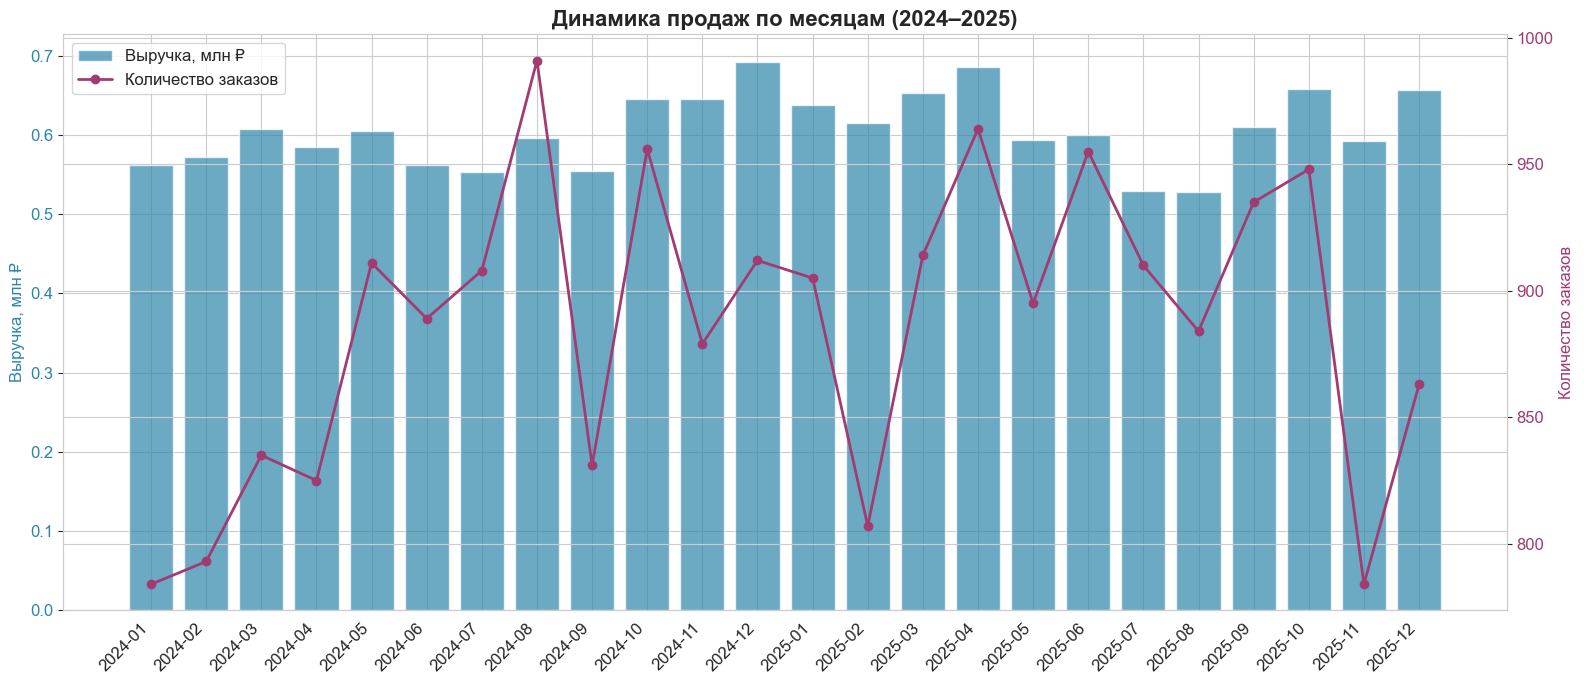

Общая выручка за 2 года: 14,537,459 ₽
Всего заказов: 21,278
Среднемесячная выручка: 605,727 ₽
Пиковая выручка: 692,344 ₽ (в 2024-12)
Минимальная выручка: 528,552 ₽ (в 2025-08)


In [27]:
sales = datasets["sales"].copy()
sales["order_month"] = sales["order_date"].dt.to_period("M")

# Количество заказов и выручка по месяцам
monthly_sales = sales.groupby("order_month").agg(
    orders=("order_id", "nunique"),
    items=("product_id", "count"),
    revenue=("unit_price", "sum")
).reset_index()
monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)

# График
fig, ax1 = plt.subplots(figsize=(16, 7))

bars = ax1.bar(monthly_sales["order_month"], monthly_sales["revenue"] / 1_000_000, 
               color=COLORS["primary"], alpha=0.7, label="Выручка, млн ₽")
ax1.set_ylabel("Выручка, млн ₽", color=COLORS["primary"])
ax1.tick_params(axis="y", labelcolor=COLORS["primary"])
ax1.set_xticklabels(monthly_sales["order_month"], rotation=45, ha="right")

ax2 = ax1.twinx()
line = ax2.plot(monthly_sales["order_month"], monthly_sales["orders"], 
                color=COLORS["secondary"], marker="o", linewidth=2, label="Количество заказов")
ax2.set_ylabel("Количество заказов", color=COLORS["secondary"])
ax2.tick_params(axis="y", labelcolor=COLORS["secondary"])

# Подписи
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Динамика продаж по месяцам (2024–2025)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Статистика
total_revenue = monthly_sales["revenue"].sum()
total_orders = monthly_sales["orders"].sum()
avg_monthly_revenue = monthly_sales["revenue"].mean()
print(f"Общая выручка за 2 года: {total_revenue:,.0f} ₽")
print(f"Всего заказов: {total_orders:,}")
print(f"Среднемесячная выручка: {avg_monthly_revenue:,.0f} ₽")
print(f"Пиковая выручка: {monthly_sales['revenue'].max():,.0f} ₽ (в {monthly_sales.loc[monthly_sales['revenue'].idxmax(), 'order_month']})")
print(f"Минимальная выручка: {monthly_sales['revenue'].min():,.0f} ₽ (в {monthly_sales.loc[monthly_sales['revenue'].idxmin(), 'order_month']})")

### 6.2. Продажи по категориям

               items     revenue  unique_products  orders  revenue_share  items_share  avg_check
category                                                                                        
Косметика      12021  5424283.61              568    9516           37.3         20.5      570.0
Бытовая химия  12042  3992789.96              565    9481           27.5         20.5      421.0
Бакалея        11434  1571542.43              568    9180           10.8         19.5      171.0
Хозтовары       8262  1442089.51              429    7052            9.9         14.1      204.0
Зоотовары       5765  1439024.98              284    5154            9.9          9.8      279.0
Напитки         9140   667728.31              423    7451            4.6         15.6       90.0


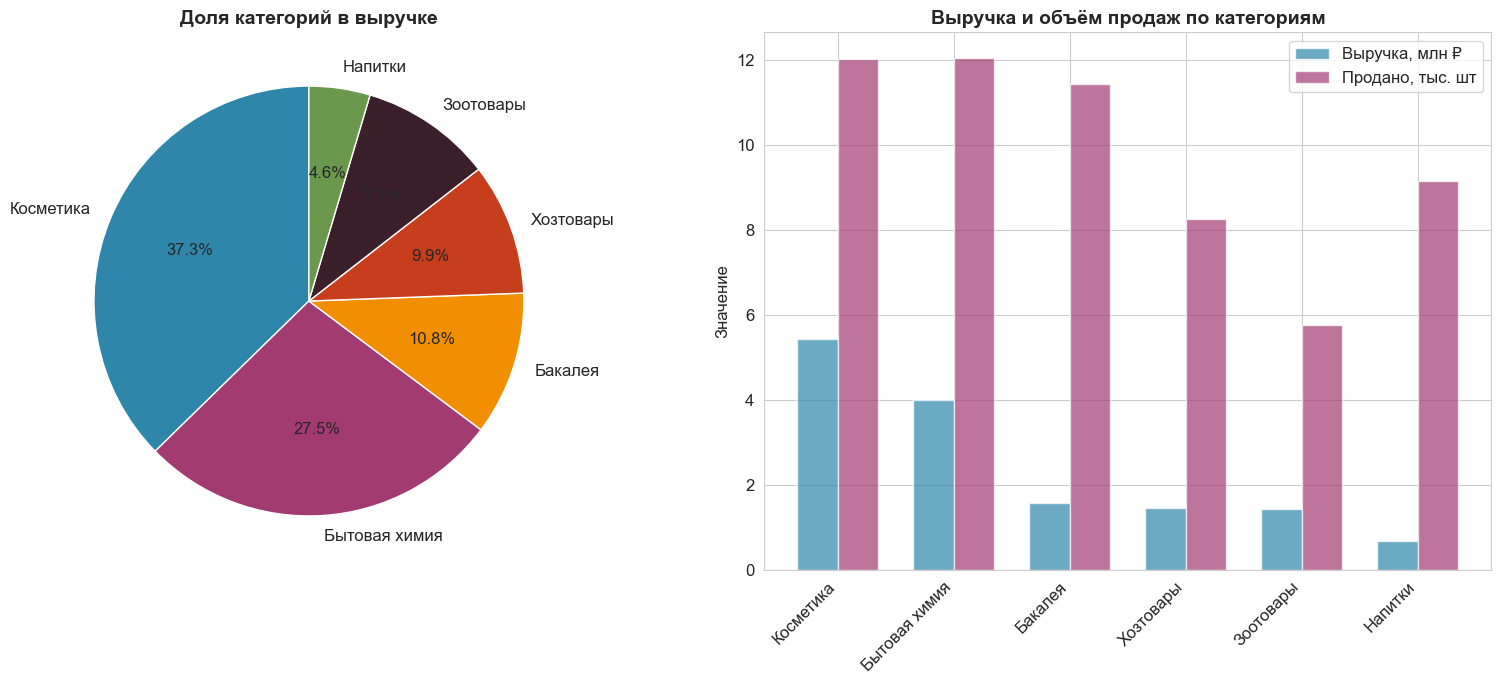

In [28]:
# Присоединяю категории из products
sales_with_cat = sales.merge(
    datasets["products"][["product_id", "category"]],
    on="product_id",
    how="left"
)

cat_stats = sales_with_cat.groupby("category", observed=False).agg(
    items=("product_id", "count"),
    revenue=("unit_price", "sum"),
    unique_products=("product_id", "nunique"),
    orders=("order_id", "nunique")
).sort_values("revenue", ascending=False)

cat_stats["revenue_share"] = (cat_stats["revenue"] / total_revenue * 100).round(1)
cat_stats["items_share"] = (cat_stats["items"] / len(sales) * 100).round(1)
cat_stats["avg_check"] = (cat_stats["revenue"] / cat_stats["orders"]).round(0)

print(cat_stats.to_string())

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Круговая диаграмма — доля в выручке
axes[0].pie(cat_stats["revenue"], labels=cat_stats.index, autopct="%1.1f%%",
            colors=COLORS["categories"][:len(cat_stats)], startangle=90)
axes[0].set_title("Доля категорий в выручке", fontsize=14, fontweight="bold")

# Столбчатая диаграмма — выручка и количество товаров
x = range(len(cat_stats))
width = 0.35
axes[1].bar([i - width/2 for i in x], cat_stats["revenue"] / 1_000_000, width,
            color=COLORS["primary"], alpha=0.7, label="Выручка, млн ₽")
axes[1].bar([i + width/2 for i in x], cat_stats["items"] / 1000, width,
            color=COLORS["secondary"], alpha=0.7, label="Продано, тыс. шт")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_stats.index, rotation=45, ha="right")
axes[1].set_ylabel("Значение")
axes[1].set_title("Выручка и объём продаж по категориям", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.3. Топ-10 товаров по продажам

In [29]:
product_stats = sales_with_cat.groupby(["product_id", "category"], observed=False).agg(
    items_sold=("product_id", "count"),
    revenue=("unit_price", "sum")
).reset_index()

product_stats = product_stats.merge(
    datasets["products"][["product_id", "product_name"]],
    on="product_id"
)

# Топ-10 по выручке
top10_revenue = product_stats.sort_values("revenue", ascending=False).head(10)
print("\nТоп-10 товаров по выручке:")
for i, (_, row) in enumerate(top10_revenue.iterrows(), 1):
    print(f"  {i}. {row['product_name'][:60]:<60} | {row['category']:<15} | "
          f"Выручка: {row['revenue']:,.0f} ₽ | Продано: {row['items_sold']} шт.")

# Топ-10 по количеству
top10_qty = product_stats.sort_values("items_sold", ascending=False).head(10)
print("\nТоп-10 товаров по количеству продаж:")
for i, (_, row) in enumerate(top10_qty.iterrows(), 1):
    print(f"  {i}. {row['product_name'][:60]:<60} | {row['category']:<15} | "
          f"Продано: {row['items_sold']} шт. | Выручка: {row['revenue']:,.0f} ₽")

# Доля топа в общей выручке
top10_revenue_share = top10_revenue["revenue"].sum() / total_revenue * 100
top10_items_share = top10_qty["items_sold"].sum() / len(sales) * 100
print(f"\nДоля топ-10 товаров в выручке: {top10_revenue_share:.1f}%")
print(f"Доля топ-10 товаров в продажах (шт): {top10_items_share:.1f}%")


Топ-10 товаров по выручке:
  1. Bourjois тушь для ресниц 377мл                               | Косметика       | Выручка: 51,144 ₽ | Продано: 73 шт.
  2. L'Oreal тональный крем 268мл                                 | Косметика       | Выручка: 46,321 ₽ | Продано: 71 шт.
  3. Nivea маска для лица 338мл                                   | Косметика       | Выручка: 45,264 ₽ | Продано: 61 шт.
  4. L'Oreal маска для лица 499мл                                 | Косметика       | Выручка: 43,530 ₽ | Продано: 56 шт.
  5. Maybelline тональный крем 253мл                              | Косметика       | Выручка: 40,729 ₽ | Продано: 58 шт.
  6. Nivea маска для лица 109мл                                   | Косметика       | Выручка: 40,655 ₽ | Продано: 58 шт.
  7. Maybelline тональный крем 80мл                               | Косметика       | Выручка: 40,396 ₽ | Продано: 59 шт.
  8. L'Oreal тональный крем 433мл                                 | Косметика       | Выручка: 38,166 ₽ | Продано: 54 

### 6.4. География и тип клиентов


Топ-10 городов по количеству клиентов:
  Москва: 680 клиентов (15.1%)
  Московская область: 550 клиентов (12.2%)
  Санкт-Петербург: 348 клиентов (7.7%)
  Нижний Новгород: 212 клиентов (4.7%)
  Краснодар: 208 клиентов (4.6%)
  Екатеринбург: 208 клиентов (4.6%)
  Новосибирск: 206 клиентов (4.6%)
  Казань: 194 клиентов (4.3%)
  Самара: 135 клиентов (3.0%)
  Уфа: 127 клиентов (2.8%)

B2C: 4258 (95%)
B2B: 242 (5%)


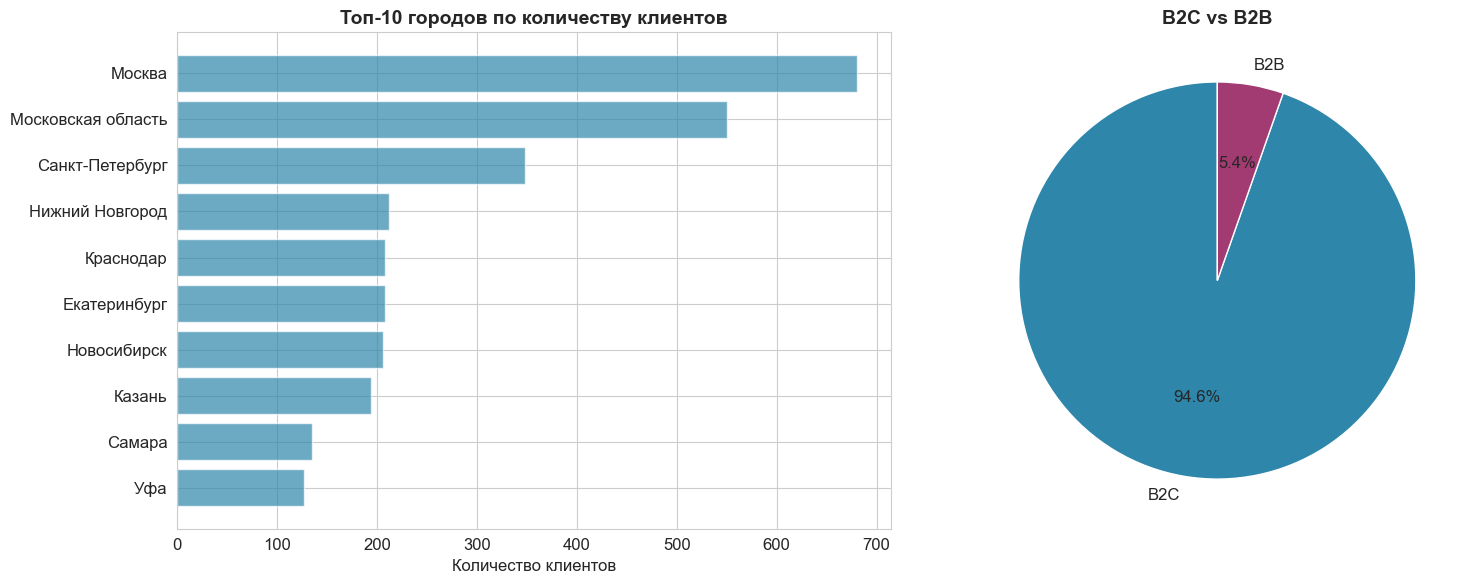

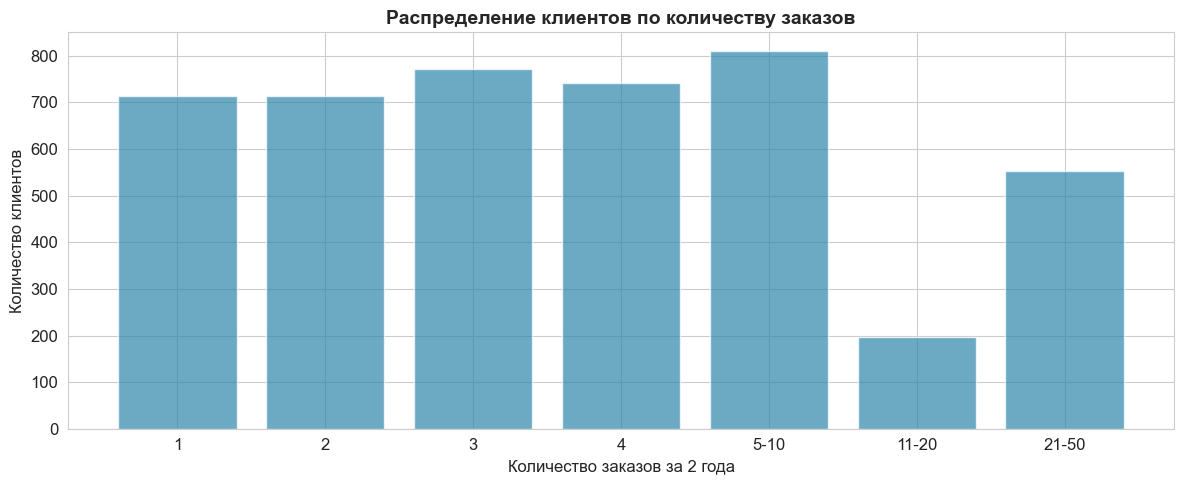


Медианное количество заказов на клиента: 4
Среднее количество заказов на клиента: 7.7


In [30]:
customers = datasets["customers"]

# Распределение по городам (топ-10)
city_counts = customers["city"].value_counts().head(10)
print("\nТоп-10 городов по количеству клиентов:")
for city, count in city_counts.items():
    print(f"  {city}: {count} клиентов ({count/len(customers)*100:.1f}%)")

# B2C vs B2B
type_counts = customers["client_type"].value_counts()
print(f"\nB2C: {type_counts.get('B2C', 0)} ({type_counts.get('B2C', 0)/len(customers)*100:.0f}%)")
print(f"B2B: {type_counts.get('B2B', 0)} ({type_counts.get('B2B', 0)/len(customers)*100:.0f}%)")

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Города
axes[0].barh(city_counts.index[::-1], city_counts.values[::-1], color=COLORS["primary"], alpha=0.7)
axes[0].set_xlabel("Количество клиентов")
axes[0].set_title("Топ-10 городов по количеству клиентов", fontsize=14, fontweight="bold")

# B2C/B2B
axes[1].pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
            colors=[COLORS["primary"], COLORS["secondary"]], startangle=90)
axes[1].set_title("B2C vs B2B", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# Распределение клиентов по количеству заказов
fig, ax = plt.subplots(figsize=(12, 5))
order_dist = customers["total_orders"].value_counts().sort_index()
# Группирую для читаемости: 1, 2, 3, 4, 5-10, 11-20, 21-50
bins = [1, 2, 3, 4, 5, 11, 21, 51]
labels = ["1", "2", "3", "4", "5-10", "11-20", "21-50"]
customers["order_group"] = pd.cut(customers["total_orders"], bins=bins, labels=labels, right=False)
order_group_counts = customers["order_group"].value_counts().sort_index()

ax.bar(range(len(order_group_counts)), order_group_counts.values, color=COLORS["primary"], alpha=0.7)
ax.set_xticks(range(len(order_group_counts)))
ax.set_xticklabels(order_group_counts.index)
ax.set_xlabel("Количество заказов за 2 года")
ax.set_ylabel("Количество клиентов")
ax.set_title("Распределение клиентов по количеству заказов", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nМедианное количество заказов на клиента: {customers['total_orders'].median():.0f}")
print(f"Среднее количество заказов на клиента: {customers['total_orders'].mean():.1f}")

### 6.5. Возвраты: динамика и причины

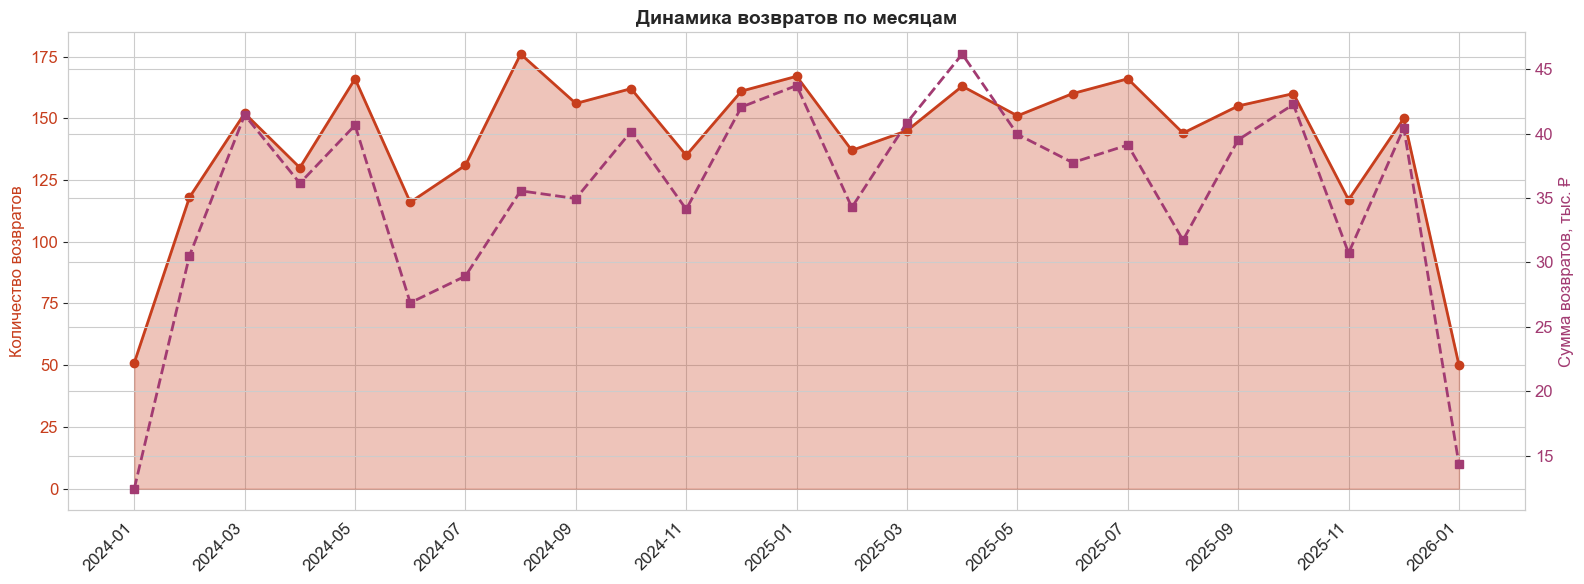


Причины возвратов:
  Передумал / не понравился: 1084 (30.8%)
  Не соответствует описанию / ожиданиям: 1050 (29.8%)
  Брак / повреждение товара: 704 (20.0%)
  Повреждение при доставке: 367 (10.4%)
  Ошибка в заказе (не тот товар): 314 (8.9%)

Статусы возвратов:
  Возвращён в оборот: 2477 (70.4%)
  Утилизация: 1042 (29.6%)

Общая сумма возвратов: 884,673 ₽
Доля возвратов в выручке: 6.1%


In [31]:
returns = datasets["returns"].copy()
returns["return_month"] = returns["return_date"].dt.to_period("M")

# Динамика по месяцам
monthly_returns = returns.groupby("return_month").agg(
    count=("return_id", "count"),
    amount=("refund_amount", "sum")
).reset_index()
monthly_returns["return_month"] = monthly_returns["return_month"].astype(str)

# График
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.fill_between(range(len(monthly_returns)), monthly_returns["count"], 
                 color=COLORS["warning"], alpha=0.3)
ax1.plot(range(len(monthly_returns)), monthly_returns["count"], 
         color=COLORS["warning"], marker="o", linewidth=2)
ax1.set_ylabel("Количество возвратов", color=COLORS["warning"])
ax1.tick_params(axis="y", labelcolor=COLORS["warning"])
ax1.set_xticks(range(0, len(monthly_returns), 2))
ax1.set_xticklabels(monthly_returns["return_month"].iloc[::2], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(range(len(monthly_returns)), monthly_returns["amount"] / 1000, 
         color=COLORS["secondary"], marker="s", linewidth=2, linestyle="--")
ax2.set_ylabel("Сумма возвратов, тыс. ₽", color=COLORS["secondary"])
ax2.tick_params(axis="y", labelcolor=COLORS["secondary"])

plt.title("Динамика возвратов по месяцам", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Причины возвратов
print("\nПричины возвратов:")
reason_stats = returns["return_reason"].value_counts()
for reason, count in reason_stats.items():
    print(f"  {reason}: {count} ({count/len(returns)*100:.1f}%)")

# Статусы возвратов
print("\nСтатусы возвратов:")
status_stats = returns["return_status"].value_counts()
for status, count in status_stats.items():
    print(f"  {status}: {count} ({count/len(returns)*100:.1f}%)")

# Доля возвратов в выручке
total_refund = returns["refund_amount"].sum()
print(f"\nОбщая сумма возвратов: {total_refund:,.0f} ₽")
print(f"Доля возвратов в выручке: {total_refund / total_revenue * 100:.1f}%")

### 6.6. Логистические затраты

                        sum  count  share  avg_per_record
cost_type                                                
delivery_to_pvz  4415490.28  58664   38.6            75.0
return_delivery   406752.00   3519    3.6           116.0
storage_fbo      6240411.19  41710   54.6           150.0
storage_pvz       371910.00  11987    3.3            31.0


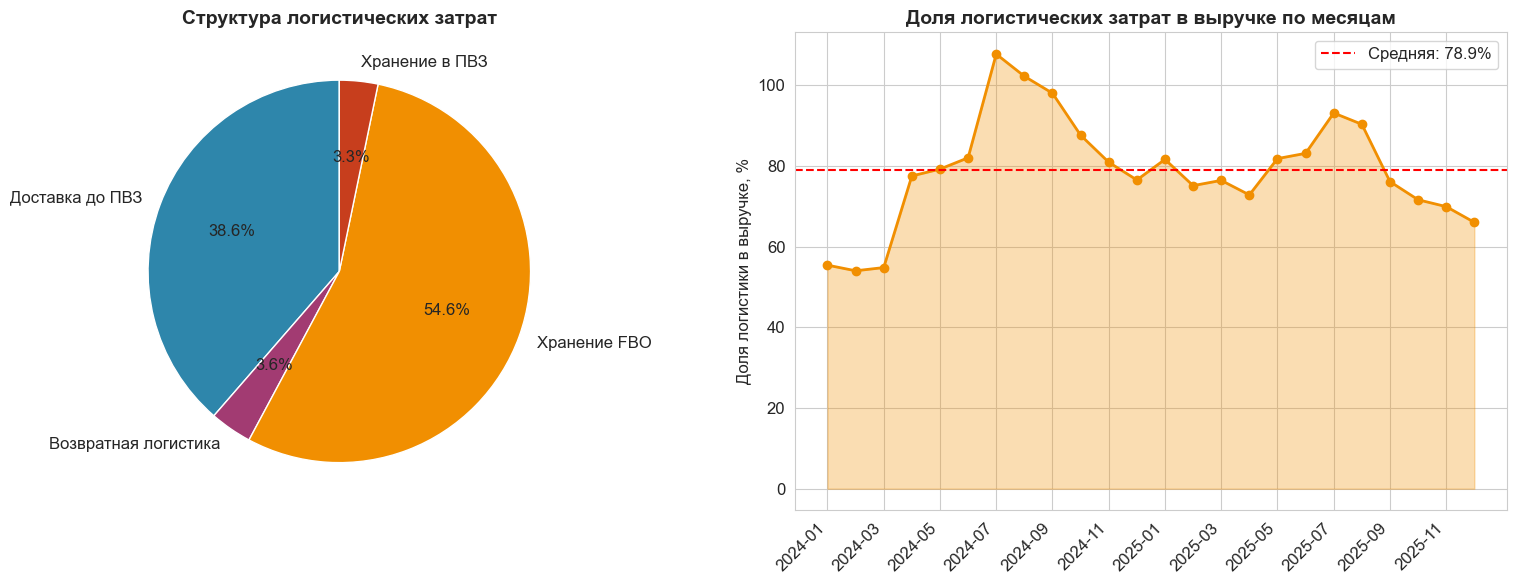


Общие затраты на логистику: 11,434,563 ₽
Доля логистики в выручке: 78.7%


In [32]:
logistics = datasets["logistics_costs"]

# Структура затрат
cost_summary = logistics.groupby("cost_type", observed=False)["cost_amount"].agg(["sum", "count"])
cost_summary["share"] = (cost_summary["sum"] / cost_summary["sum"].sum() * 100).round(1)
cost_summary["avg_per_record"] = (cost_summary["sum"] / cost_summary["count"]).round(0)
print(cost_summary.to_string())

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Круговая диаграмма — структура затрат
cost_labels = {
    "delivery_to_pvz": "Доставка до ПВЗ",
    "storage_fbo": "Хранение FBO",
    "storage_pvz": "Хранение в ПВЗ",
    "return_delivery": "Возвратная логистика"
}
labels = [cost_labels.get(t, t) for t in cost_summary.index]
axes[0].pie(cost_summary["sum"], labels=labels, autopct="%1.1f%%",
            colors=COLORS["categories"][:4], startangle=90)
axes[0].set_title("Структура логистических затрат", fontsize=14, fontweight="bold")

# Доля логистики в выручке по месяцам
logistics["cost_month"] = logistics["cost_date"].dt.to_period("M")
monthly_logistics = logistics.groupby("cost_month")["cost_amount"].sum().reset_index()
monthly_logistics["cost_month"] = monthly_logistics["cost_month"].astype(str)

monthly_metrics = monthly_sales.merge(monthly_logistics, left_on="order_month", right_on="cost_month", how="left")
monthly_metrics["logistics_share"] = (monthly_metrics["cost_amount"] / monthly_metrics["revenue"] * 100).round(1)

axes[1].fill_between(range(len(monthly_metrics)), monthly_metrics["logistics_share"],
                     color=COLORS["accent"], alpha=0.3)
axes[1].plot(range(len(monthly_metrics)), monthly_metrics["logistics_share"],
             color=COLORS["accent"], marker="o", linewidth=2)
axes[1].axhline(y=monthly_metrics["logistics_share"].mean(), color="red", 
                linestyle="--", label=f"Средняя: {monthly_metrics['logistics_share'].mean():.1f}%")
axes[1].set_ylabel("Доля логистики в выручке, %")
axes[1].set_xticks(range(0, len(monthly_metrics), 2))
axes[1].set_xticklabels(monthly_metrics["order_month"].iloc[::2], rotation=45, ha="right")
axes[1].set_title("Доля логистических затрат в выручке по месяцам", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

total_logistics = cost_summary["sum"].sum()
print(f"\nОбщие затраты на логистику: {total_logistics:,.0f} ₽")
print(f"Доля логистики в выручке: {total_logistics / total_revenue * 100:.1f}%")

### 6.7. Выводы по распределениям

**Продажи:**
- Выручка за 2 года составила **14.5 млн ₽**, всего **21 278 заказов**.
- Среднемесячная выручка — **606 тыс. ₽**, колебания от 529 тыс. до 692 тыс. ₽. Ярко выраженных сезонных всплесков нет — бизнес относительно стабилен по месяцам.
- **Косметика** и **Бытовая химия** — категории-лидеры: вместе дают **64.8% выручки** при 41% проданных товаров. У них же самый высокий средний чек (570 ₽ и 421 ₽ соответственно).
- **Напитки** — самая низкомаржинальная категория (средний чек 90 ₽, доля в выручке 4.6% при 15.6% в объёме).
- Топ-10 товаров по выручке — полностью косметика, но их совокупная доля всего **2.9%**. Это говорит о **низкой концентрации**: бизнес не зависит от нескольких хитов, ассортимент диверсифицирован.
- Топ-10 по количеству продаж показывает другую картину: лидируют товары повседневного спроса из Бакалеи, Зоотоваров и Бытовая химии — это товары-«трафикогенераторы» с невысоким чеком.

**Клиенты:**
- **57.3% клиентов** сконцентрированы в Москве, Московской области и Санкт-Петербурге. Это снижает логистические риски, но указывает на потенциал региональной экспансии.
- B2B-клиенты составляют **5% базы** — стоит проанализировать их средний чек и LTV в ноутбуке 03.
- Медианное количество заказов — **4**, среднее — **7.7**. Распределение смещено вправо: есть ядро активных клиентов, делающих 20+ заказов. Их удержание — ключевой фактор роста.

**Возвраты:**
- Доля возвратов — **6.1% от выручки** (885 тыс. ₽), что в рамках допустимого для e-commerce.
- Основные причины: «передумал» (30.8%) и «не соответствует описанию» (29.8%) — **60% возвратов можно сократить** улучшением контента (фото, видео, описания) и упаковки.
- **70% возвратов возвращаются в оборот**, 30% утилизируются. Утилизация — прямые убытки: потеря себестоимости + логистика. Разберу в ноутбуке 02.

**Логистика:**
- **78.7% от выручки уходит на логистику** — критический показатель. Норма для e-commerce — 15–30%.
- Главный «пожиратель» маржи — **хранение на складе FBO: 6.2 млн ₽ (54.6% затрат)**. Это прямое следствие затоваривания: товары лежат на складе и генерируют убытки.
- Доставка до ПВЗ — 4.4 млн ₽ (38.6% затрат) — в пределах ожидаемого для модели с региональной доставкой и FBS.
- **Ключевая проблема бизнеса — управление запасами.** Детально разберу в ноутбуке 04.

**Дальнейшие шаги:**
- **Ноутбук 02:** Маржинальный анализ — какие товары и категории реально приносят прибыль с учётом логистики и возвратов?
- **Ноутбук 03:** RFM, когорты, LTV — кто наши лучшие клиенты и как их удерживать?
- **Ноутбук 04:** Оборачиваемость и неликвиды — сколько денег заморожено в запасах и как сократить затраты на хранение?